In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

tmin = -.5
tmax=2.0
fmin=0.5
fmax = 16
sfreq = 32

paradigm = MotorImagery(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax,  n_classes=7)
dataset= Weibo2014()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
"""
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
"""

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
Choosing from all possible events


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


Trial data de-meaned and concatenated with a buffer to create cont data


Adding metadata with 3 columns
Adding metadata with 3 columns
560 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


"\nsession = meta['session'][0]\nidc = meta['session'] == session\nepochs = epochs[idc]\nlabels = labels[idc]\nmeta = meta[idc]\n"

In [3]:
epochs

Number of events,560
Events,feet: 80hands: 80left_hand: 80left_hand_right_foot: 80rest: 80right_hand: 80right_hand_left_foot: 80
Time range,2.500 – 4.969 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
555,1,0,0
556,1,0,0
557,1,0,0
558,1,0,0


No projector specified for this dataset. Please consider the method self.add_proj.


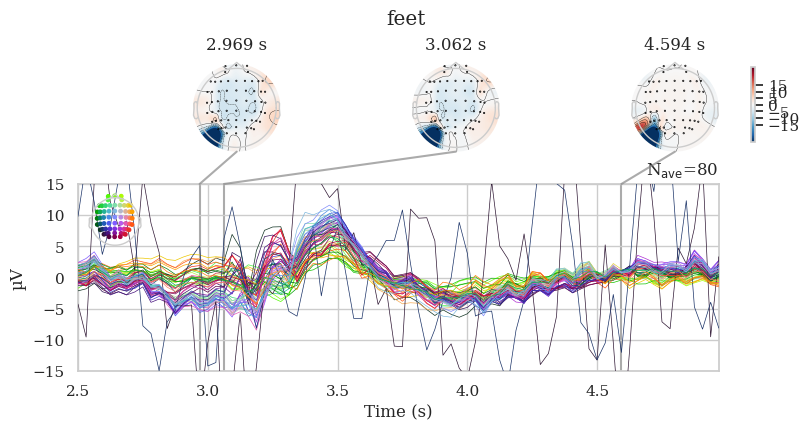

No projector specified for this dataset. Please consider the method self.add_proj.


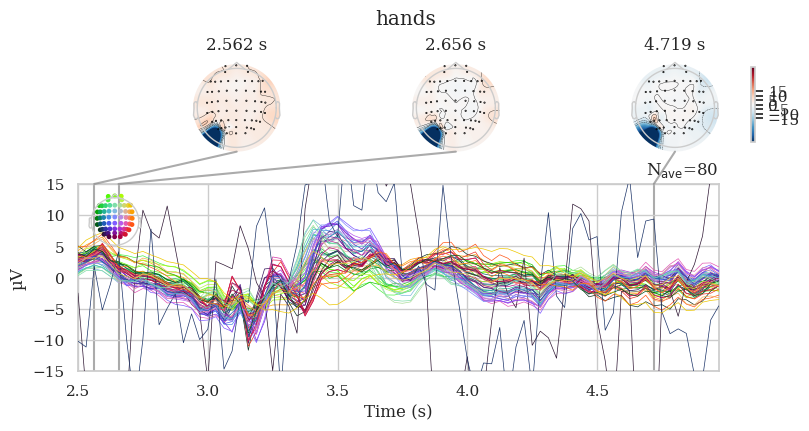

No projector specified for this dataset. Please consider the method self.add_proj.


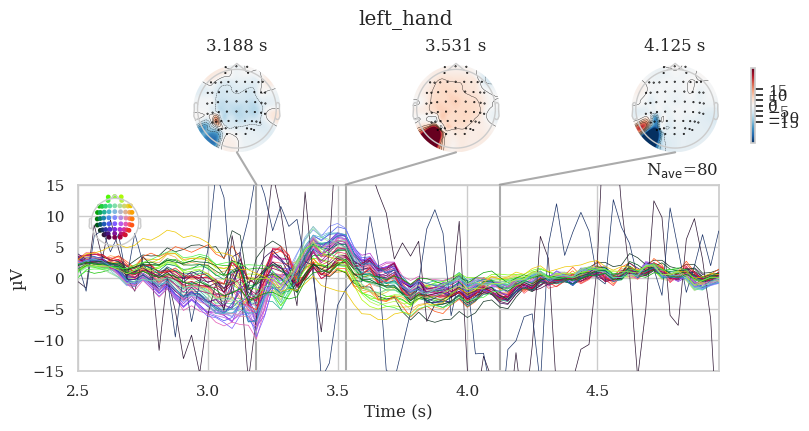

No projector specified for this dataset. Please consider the method self.add_proj.


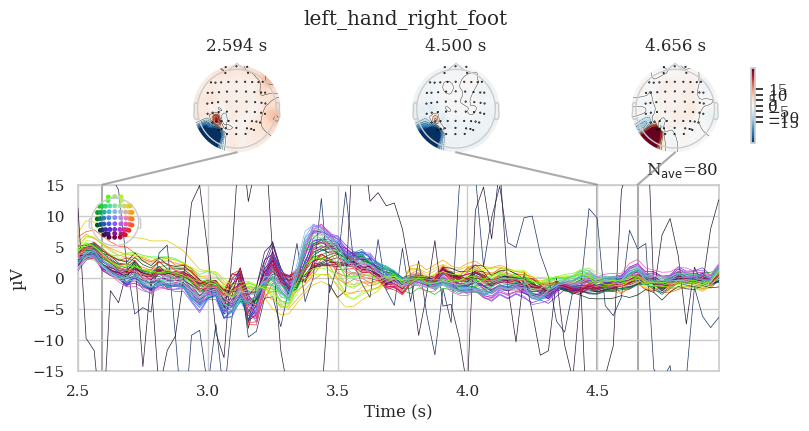

No projector specified for this dataset. Please consider the method self.add_proj.


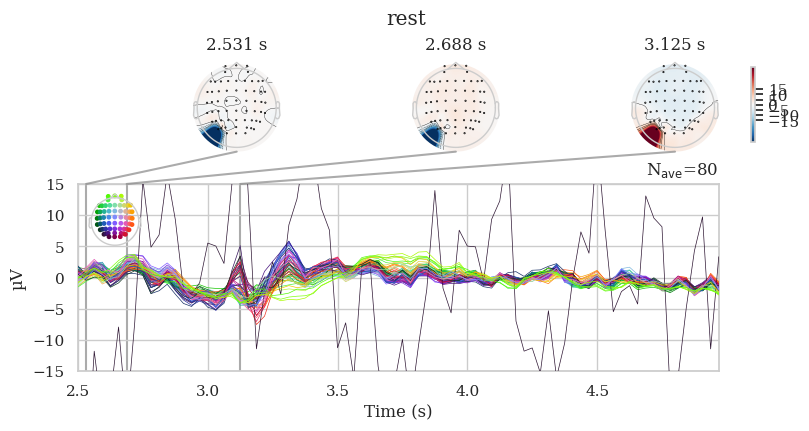

No projector specified for this dataset. Please consider the method self.add_proj.


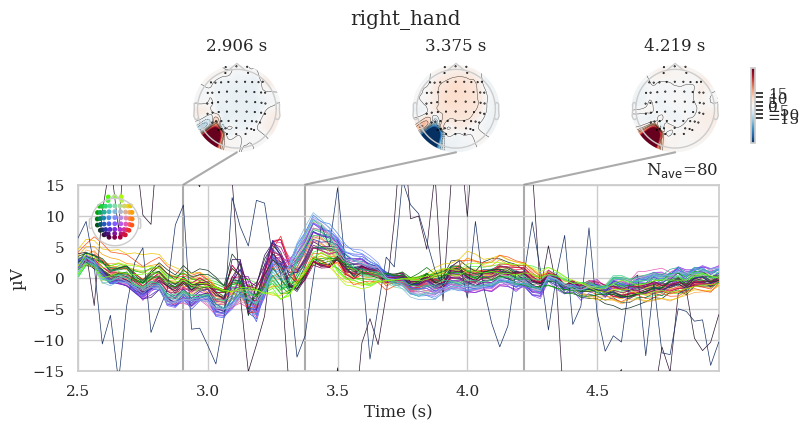

No projector specified for this dataset. Please consider the method self.add_proj.


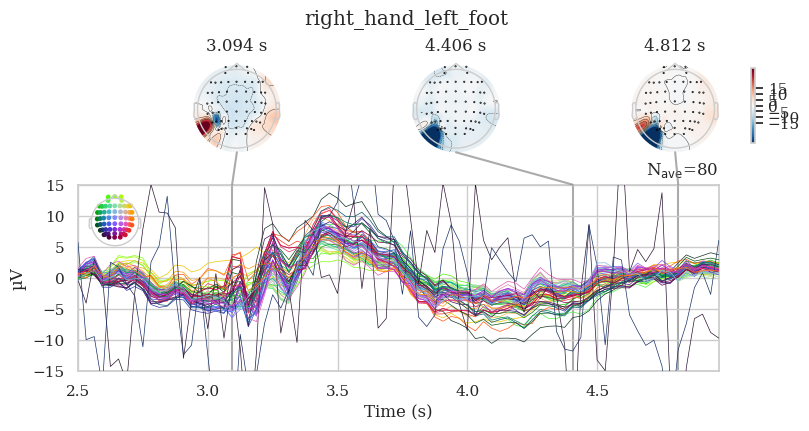

In [5]:
import numpy as np
ts_args=dict(ylim=dict(eeg=[-15,15]))
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_1149/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(560, 60, 80)

In [7]:
from hoda.hoda import aHODA, f_multiway
from hoda.gpu_opt import center
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues

hoda = aHODA(
            rank=None,
            max_iter=256,
            tol=1e-8,
            init ='mlsvd',
            shrinkage='lw',
            toeplitz=None,
            taper=False,
            obj='rt',
            solver='lanczos',
            keep_train_info=False,
            verbose=True,
        )
hoda.fit(X,y)

ImportError: cannot import name 'aHODA' from 'hoda.hoda' (/project/src/hoda/hoda.py)

In [ ]:
hoda.train_info_

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_, x='iteration', y='F', ax=axs[0])
    axs[1].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='p', ax=axs[1])
    axs[1].set(yscale='log')
    sns.lineplot(data=hoda.train_info_, x='iteration', y='mse', ax=axs[2])
    axs[2].set(yscale="log")
    axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")


    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='shrinkage',hue='mode', ax=axs[3])

In [ ]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

if len(epochs.ch_names)>1:
    n_col = col_wrap
    n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col, layout='tight')
    for i in range(hoda.rank_(0)):
        w = tl.to_numpy(hoda.scalings_[0][:,i])
        plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)


In [ ]:
n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


In [ ]:
if len(epochs.ch_names)>1:

    n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col, layout='tight')
    A = hoda.aps_[0]
    for i in range(hoda.rank_(0)):
        a = tl.to_numpy(A[:,i])
        plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)



In [ ]:

n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

In [ ]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov =  tl.to_numpy(hoda.cov_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [ ]:
Xt = hoda.transform(X)

In [ ]:
X.shape

In [ ]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

snr,p = f_multiway(X,y)
F, p = f_oneway(Xt,y)


Xsq_sp, p_sp = combine_pvalues(p, axis=(1,))
Xsq_tmp, p_tmp = combine_pvalues(p, axis=(0,))
print(p_sp)
print(p_tmp)

Xsq_sp = tl.to_numpy(Xsq_sp)
Xsq_tmp = tl.to_numpy(Xsq_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, Xsq_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, Xsq_sp)

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

X_viz = X.reshape((X.shape[0],-1))
Xt_viz = Xt.reshape((Xt.shape[0],-1))
n_components = 2
decomp  = PCA(n_components=n_components, whiten=True)
X_viz = decomp.fit_transform(tl.to_numpy(X_viz))
Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_viz))

df = pd.DataFrame(Xt_viz)
df['label'] = labels
sns.scatterplot(data=df, x=0, y=1, hue='label')

In [ ]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls, **joint_args)
    else:
        evoked_rec.plot(**ts_args)